In [ ]:
import os
from getpass import getpass

os.environ["KAGGLE_API_TOKEN"] = getpass("Enter your Kaggle API token: ")

Enter your Kaggle API token: ··········


In [ ]:
!pip install -q kaggle

In [ ]:
!kaggle datasets download -d ashishmotwani/tomato -p /content


Dataset URL: https://www.kaggle.com/datasets/ashishmotwani/tomato
License(s): copyright-authors
100% 1.37G/1.37G [00:14<00:00, 102MB/s] 



In [ ]:
!ls -lh /content

total 1.4G
drwxr-xr-x 1 root root 4.0K Jun  4 13:39 sample_data
-rw-r--r-- 1 root root 1.4G Oct 25  2022 tomato.zip


In [ ]:
import zipfile
import os

zip_path = "/content/tomato.zip"
extract_path = "/content/dataset"

os.makedirs(extract_path, exist_ok=True)

with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall(extract_path)

print(os.listdir(extract_path))

['train', 'valid']


In [ ]:
import os
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.callbacks import (
    EarlyStopping,
    ModelCheckpoint,
    ReduceLROnPlateau
)

print("TensorFlow:", tf.__version__)
print("GPU:", tf.config.list_physical_devices("GPU"))

TensorFlow: 2.20.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [ ]:
# Paths
TRAIN_DIR = "/content/dataset/train"
VALID_DIR = "/content/dataset/valid"

# Configuration
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
INITIAL_EPOCHS = 8
FINE_TUNE_EPOCHS = 8

SEED = 42

# Automatically determine number of classes
class_names = sorted([
    name for name in os.listdir(TRAIN_DIR)
    if os.path.isdir(os.path.join(TRAIN_DIR, name))
])

NUM_CLASSES = len(class_names)

print("Classes:", class_names)
print("Number of classes:", NUM_CLASSES)

Classes: ['Bacterial_spot', 'Early_blight', 'Late_blight', 'Leaf_Mold', 'Septoria_leaf_spot', 'Spider_mites Two-spotted_spider_mite', 'Target_Spot', 'Tomato_Yellow_Leaf_Curl_Virus', 'Tomato_mosaic_virus', 'healthy', 'powdery_mildew']
Number of classes: 11


In [ ]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    labels="inferred",
    label_mode="categorical",
    class_names=class_names,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True,
    seed=SEED
)

valid_ds = tf.keras.utils.image_dataset_from_directory(
    VALID_DIR,
    labels="inferred",
    label_mode="categorical",
    class_names=class_names,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

Found 25851 files belonging to 11 classes.
Found 6683 files belonging to 11 classes.


In [ ]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.prefetch(AUTOTUNE)
valid_ds = valid_ds.prefetch(AUTOTUNE)

In [ ]:
data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
    layers.RandomContrast(0.1),
], name="data_augmentation")

In [ ]:
base_model = EfficientNetB0(
    include_top=False,
    weights="imagenet",
    input_shape=(224, 224, 3)
)

base_model.trainable = False

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
base_model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=1e-3
    ),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

In [ ]:
import os

os.makedirs("/content/models", exist_ok=True)

callbacks = [
    tf.keras.callbacks.ModelCheckpoint(
        "/content/models/best_model.keras",
        monitor="val_accuracy",
        save_best_only=True,
        mode="max",
        verbose=1
    ),

    tf.keras.callbacks.EarlyStopping(
        monitor="val_accuracy",
        patience=3,
        mode="max",
        restore_best_weights=True,
        verbose=1
    ),

    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.2,
        patience=2,
        min_lr=1e-7,
        verbose=1
    )
]

In [ ]:
# Make sure EfficientNet-B0 remains frozen for initial training
base_model.trainable = False

# Input
inputs = keras.Input(shape=(224, 224, 3))

# Data augmentation
x = data_augmentation(inputs)

# EfficientNet-B0 feature extractor
x = base_model(x, training=False)

# Convert feature maps into a single feature vector
x = layers.GlobalAveragePooling2D()(x)

# Prevent overfitting
x = layers.Dropout(0.3)(x)

# Classification layer
outputs = layers.Dense(
    NUM_CLASSES,
    activation="softmax"
)(x)

# Complete model
model = keras.Model(
    inputs=inputs,
    outputs=outputs,
    name="PlantHealth_EfficientNetB0"
)

model.summary()

Model: "PlantHealth_EfficientNetB0"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 11)             │        14,091 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,063,662 (15.50 MB)

 Trainable params: 14,091 (55.04 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

In [ ]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=1e-3
    ),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

In [ ]:
print("Base model output:", base_model.output_shape)
print("Complete model output:", model.output_shape)

Base model output: (None, 7, 7, 1280)
Complete model output: (None, 11)


In [ ]:
history_initial = model.fit(
    train_ds,
    validation_data=valid_ds,
    epochs=8,
    callbacks=callbacks
)

# Print final training results
print("\n" + "=" * 60)
print("INITIAL TRAINING RESULTS")
print("=" * 60)

# Best epoch based on validation accuracy
best_epoch = np.argmax(history_initial.history["val_accuracy"]) + 1

best_train_acc = history_initial.history["accuracy"][best_epoch - 1]
best_val_acc = history_initial.history["val_accuracy"][best_epoch - 1]
best_train_loss = history_initial.history["loss"][best_epoch - 1]
best_val_loss = history_initial.history["val_loss"][best_epoch - 1]

print(f"Best Epoch          : {best_epoch}")
print(f"Training Accuracy   : {best_train_acc:.4f}")
print(f"Validation Accuracy : {best_val_acc:.4f}")
print(f"Training Loss       : {best_train_loss:.4f}")
print(f"Validation Loss     : {best_val_loss:.4f}")

print("=" * 60)

Epoch 1/8
808/808 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step - accuracy: 0.5586 - loss: 1.4114
Epoch 1: val_accuracy improved from None to 0.78288, saving model to /content/models/best_model.keras

Epoch 1: finished saving model to /content/models/best_model.keras
808/808 ━━━━━━━━━━━━━━━━━━━━ 89s 110ms/step - accuracy: 0.6735 - loss: 1.0652 - val_accuracy: 0.7829 - val_loss: 0.7055 - learning_rate: 0.0010
Epoch 2/8
808/808 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step - accuracy: 0.7773 - loss: 0.7133
Epoch 2: val_accuracy improved from 0.78288 to 0.82283, saving model to /content/models/best_model.keras

Epoch 2: finished saving model to /content/models/best_model.keras
808/808 ━━━━━━━━━━━━━━━━━━━━ 86s 106ms/step - accuracy: 0.7847 - loss: 0.6880 - val_accuracy: 0.8228 - val_loss: 0.5697 - learning_rate: 0.0010
Epoch 3/8
808/808 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step - accuracy: 0.8030 - loss: 0.6207
Epoch 3: val_accuracy improved from 0.82283 to 0.82613, saving model to /content/models/best_model.keras

Epoch

In [ ]:
# Unfreeze the EfficientNet backbone
base_model.trainable = True

# Freeze the earlier layers and fine-tune only the later layers
fine_tune_from = 200

for layer in base_model.layers[:fine_tune_from]:
    layer.trainable = False

for layer in base_model.layers[fine_tune_from:]:
    layer.trainable = True

print("Total layers:", len(base_model.layers))
print("Trainable layers:", sum(layer.trainable for layer in base_model.layers))

Total layers: 238
Trainable layers: 38


In [ ]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=1e-5
    ),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

In [ ]:
fine_tune_callbacks = [
    tf.keras.callbacks.ModelCheckpoint(
        "/content/models/best_model_finetuned.keras",
        monitor="val_accuracy",
        save_best_only=True,
        mode="max",
        verbose=1
    ),

    tf.keras.callbacks.EarlyStopping(
        monitor="val_accuracy",
        patience=3,
        mode="max",
        restore_best_weights=True,
        verbose=1
    ),

    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.2,
        patience=2,
        min_lr=1e-7,
        verbose=1
    )
]

In [ ]:
history_finetune = model.fit(
    train_ds,
    validation_data=valid_ds,
    epochs=8,
    callbacks=fine_tune_callbacks
)

# Print Stage 2 results
print("\n" + "=" * 60)
print("FINE-TUNING RESULTS")
print("=" * 60)

best_epoch = np.argmax(
    history_finetune.history["val_accuracy"]
) + 1

best_train_acc = history_finetune.history["accuracy"][best_epoch - 1]
best_val_acc = history_finetune.history["val_accuracy"][best_epoch - 1]
best_train_loss = history_finetune.history["loss"][best_epoch - 1]
best_val_loss = history_finetune.history["val_loss"][best_epoch - 1]

print(f"Best Epoch          : {best_epoch}")
print(f"Training Accuracy   : {best_train_acc:.4f}")
print(f"Validation Accuracy : {best_val_acc:.4f}")
print(f"Training Loss       : {best_train_loss:.4f}")
print(f"Validation Loss     : {best_val_loss:.4f}")

print("=" * 60)

# Compare with Stage 1
stage1_best_val = max(history_initial.history["val_accuracy"])
stage2_best_val = max(history_finetune.history["val_accuracy"])

print(f"\nStage 1 Best Validation Accuracy : {stage1_best_val:.4f}")
print(f"Stage 2 Best Validation Accuracy : {stage2_best_val:.4f}")
print(f"Improvement                       : {(stage2_best_val - stage1_best_val):+.4f}")

Epoch 1/8
808/808 ━━━━━━━━━━━━━━━━━━━━ 0s 106ms/step - accuracy: 0.6868 - loss: 0.9593
Epoch 1: val_accuracy improved from None to 0.82478, saving model to /content/models/best_model_finetuned.keras

Epoch 1: finished saving model to /content/models/best_model_finetuned.keras
808/808 ━━━━━━━━━━━━━━━━━━━━ 123s 133ms/step - accuracy: 0.7223 - loss: 0.8417 - val_accuracy: 0.8248 - val_loss: 0.5062 - learning_rate: 1.0000e-05
Epoch 2/8
808/808 ━━━━━━━━━━━━━━━━━━━━ 0s 105ms/step - accuracy: 0.7909 - loss: 0.6248
Epoch 2: val_accuracy improved from 0.82478 to 0.85156, saving model to /content/models/best_model_finetuned.keras

Epoch 2: finished saving model to /content/models/best_model_finetuned.keras
808/808 ━━━━━━━━━━━━━━━━━━━━ 106s 131ms/step - accuracy: 0.7997 - loss: 0.5996 - val_accuracy: 0.8516 - val_loss: 0.4192 - learning_rate: 1.0000e-05
Epoch 3/8
808/808 ━━━━━━━━━━━━━━━━━━━━ 0s 105ms/step - accuracy: 0.8242 - loss: 0.5295
Epoch 3: val_accuracy improved from 0.85156 to 0.87146, sa

In [ ]:
best_model = tf.keras.models.load_model(
    "/content/models/best_model_finetuned.keras"
)

print("Best fine-tuned model loaded successfully.")

Best fine-tuned model loaded successfully.


/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 74 variables whereas the saved optimizer has 2 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


In [ ]:
from sklearn.metrics import classification_report
import numpy as np

y_true = []
y_pred = []

for images, labels in valid_ds:
    predictions = best_model.predict(images, verbose=0)

    y_true.extend(np.argmax(labels.numpy(), axis=1))
    y_pred.extend(np.argmax(predictions, axis=1))

print(
    classification_report(
        y_true,
        y_pred,
        target_names=class_names,
        digits=4
    )
)

                                      precision    recall  f1-score   support

                      Bacterial_spot     0.9567    0.8743    0.9136       732
                        Early_blight     0.8946    0.8709    0.8826       643
                         Late_blight     0.8837    0.9306    0.9065       792
                           Leaf_Mold     0.9442    0.9161    0.9299       739
                  Septoria_leaf_spot     0.8669    0.8646    0.8658       746
Spider_mites Two-spotted_spider_mite     0.9368    0.9195    0.9281       435
                         Target_Spot     0.7786    0.9540    0.8574       457
       Tomato_Yellow_Leaf_Curl_Virus     0.9919    0.9779    0.9848       498
                 Tomato_mosaic_virus     0.9981    0.9195    0.9572       584
                             healthy     0.9600    0.9826    0.9711       805
                      powdery_mildew     0.9249    0.9286    0.9267       252

                            accuracy                         0

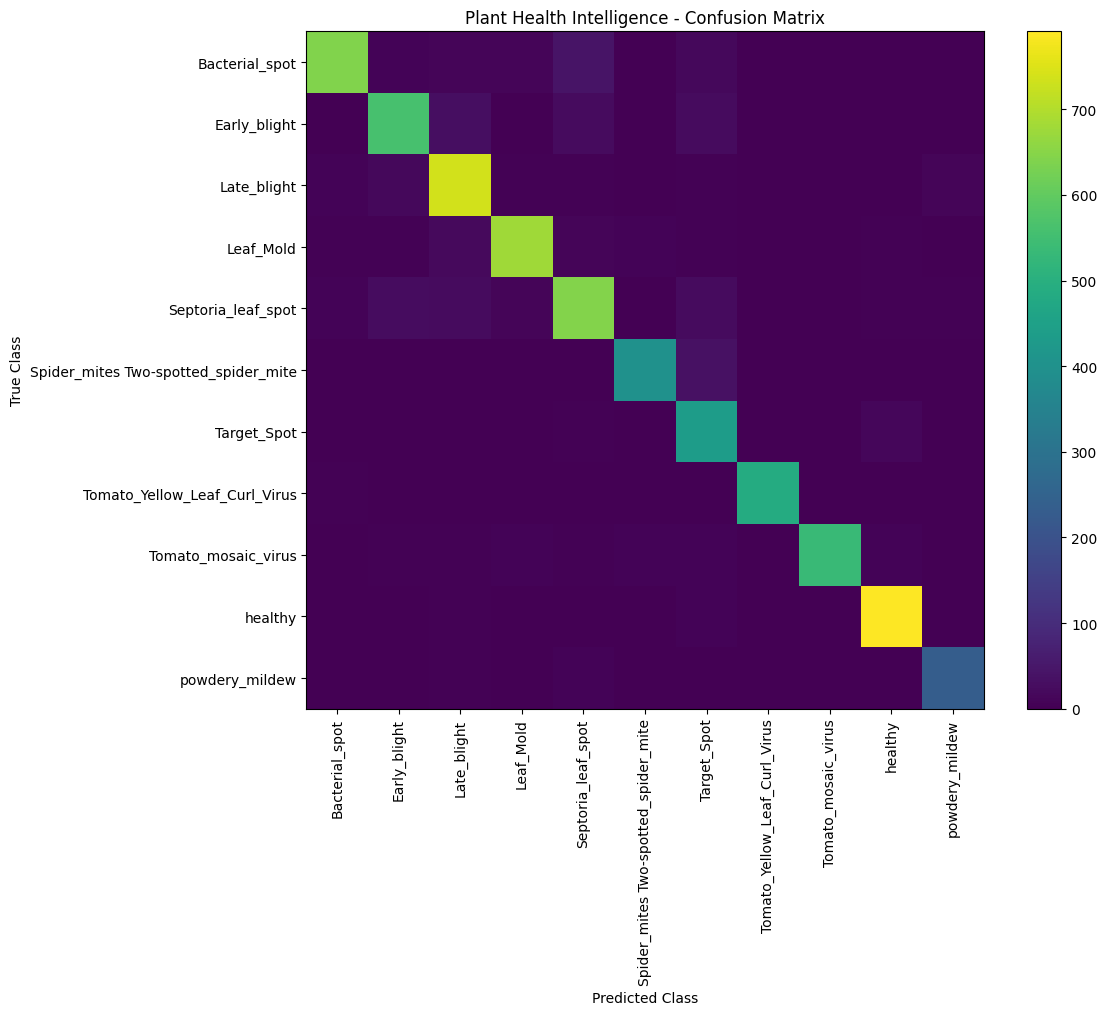

In [ ]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(12, 10))
plt.imshow(cm)
plt.title("Plant Health Intelligence - Confusion Matrix")
plt.xlabel("Predicted Class")
plt.ylabel("True Class")
plt.colorbar()

plt.xticks(
    range(len(class_names)),
    class_names,
    rotation=90
)

plt.yticks(
    range(len(class_names)),
    class_names
)

plt.tight_layout()

plt.savefig(
    "/content/models/confusion_matrix.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()

In [ ]:
from google.colab import files

files.download("/content/models/best_model_finetuned.keras")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import os

model_path = "/content/models/best_model_finetuned.keras"

print("Exists:", os.path.exists(model_path))
print("Size:", os.path.getsize(model_path) / (1024 * 1024), "MB")

Exists: True
Size: 32.101810455322266 MB


In [ ]:
print(class_names)

['Bacterial_spot', 'Early_blight', 'Late_blight', 'Leaf_Mold', 'Septoria_leaf_spot', 'Spider_mites Two-spotted_spider_mite', 'Target_Spot', 'Tomato_Yellow_Leaf_Curl_Virus', 'Tomato_mosaic_virus', 'healthy', 'powdery_mildew']
